# Quiz 3(100 points total)
The deliverable of this quiz is this jupyter-notebook completed with your solution.

If not necessary, you are <b>not allowed</b> to change the code that are provided, you are being assessed based on:
  - 1. Code execution - 25%
  - 2. Clarity of the code (e.g., easy to follow, has pertinent comments, etc.) - 25%
  - 3. Proper usage of the techniques seen in class - 25%
  - 4. Quality and correcteness of the results - 25%

  
      
## Importing Python Libraries

In [3]:
# Install necessary libaries to retrieve data from Kaggle
!pip install opendatasets
!pip install pandas

In [4]:
%matplotlib inline
import matplotlib.pylab as plt
import numpy as np
import tensorflow as tf


In [7]:
import opendatasets as od
import pandas

od.download(
    "https://www.kaggle.com/competitions/playground-series-s4e8")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kyschwartz
Your Kaggle Key: ··········


100%|██████████| 82.3M/82.3M [00:01<00:00, 68.1MB/s]



Extracting archive ./playground-series-s4e8/playground-series-s4e8.zip to ./playground-series-s4e8


In [10]:
import pandas
testcsvFile = pandas.read_csv('playground-series-s4e8/\
test.csv')
print(testcsvFile)
traincsvFile = pandas.read_csv('playground-series-s4e8/\
train.csv')
print(traincsvFile)

              id  cap-diameter cap-shape cap-surface cap-color  \
0        3116945          8.64         x         NaN         n   
1        3116946          6.90         o           t         o   
2        3116947          2.00         b           g         n   
3        3116948          3.47         x           t         n   
4        3116949          6.17         x           h         y   
...          ...           ...       ...         ...       ...   
2077959  5194904          0.88         x           g         w   
2077960  5194905          3.12         x           s         w   
2077961  5194906          5.73         x           e         e   
2077962  5194907          5.03         b           g         n   
2077963  5194908         15.51         f         NaN         w   

        does-bruise-or-bleed gill-attachment gill-spacing gill-color  \
0                          t             NaN          NaN          w   
1                          f             NaN            c      

## Load dataset, explore it  and split it into train, validation and test sets

- [Load CIFAR-10 Keras](https://www.cs.toronto.edu/~kriz/cifar.html)

In [ ]:
# Loading the data using the Keras function
(X_dev, Y_dev), (X_test, Y_test) = tf.keras.datasets.cifar10.load_data() # The data comes already split
                                                                        # in dev and test sets
print("Development set")
print("Images: ",X_dev.shape)
print("Labels shape:",Y_dev.shape)
print("\nNumber of classes:",np.unique(Y_dev).size)
print("\nClasses:",np.unique(Y_dev))
print("\nTest set")
print("Images: ",X_test.shape)
print("Labels shape: ",Y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 69s 0us/step
Development set
Images:  (50000, 32, 32, 3)
Labels shape: (50000, 1)

Number of classes: 10

Classes: [0 1 2 3 4 5 6 7 8 9]

Test set
Images:  (10000, 32, 32, 3)
Labels shape:  (10000, 1)


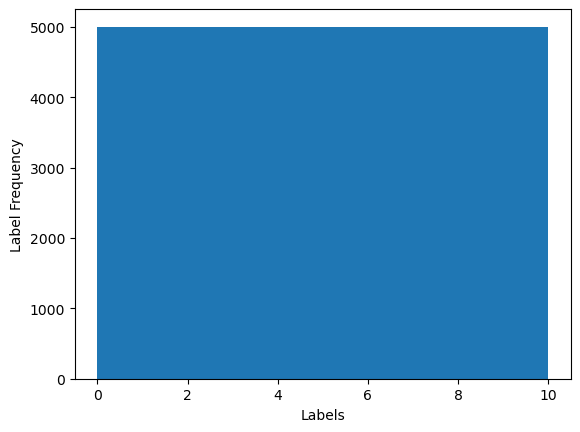

In [ ]:
plt.figure()
plt.hist(Y_dev, bins = range(11))
plt.xlabel("Labels")
plt.ylabel("Label Frequency")
plt.show()

C:\Users\kyboo\AppData\Local\Temp\ipykernel_44604\314830093.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title("Label: %d" %Y_dev[jj])


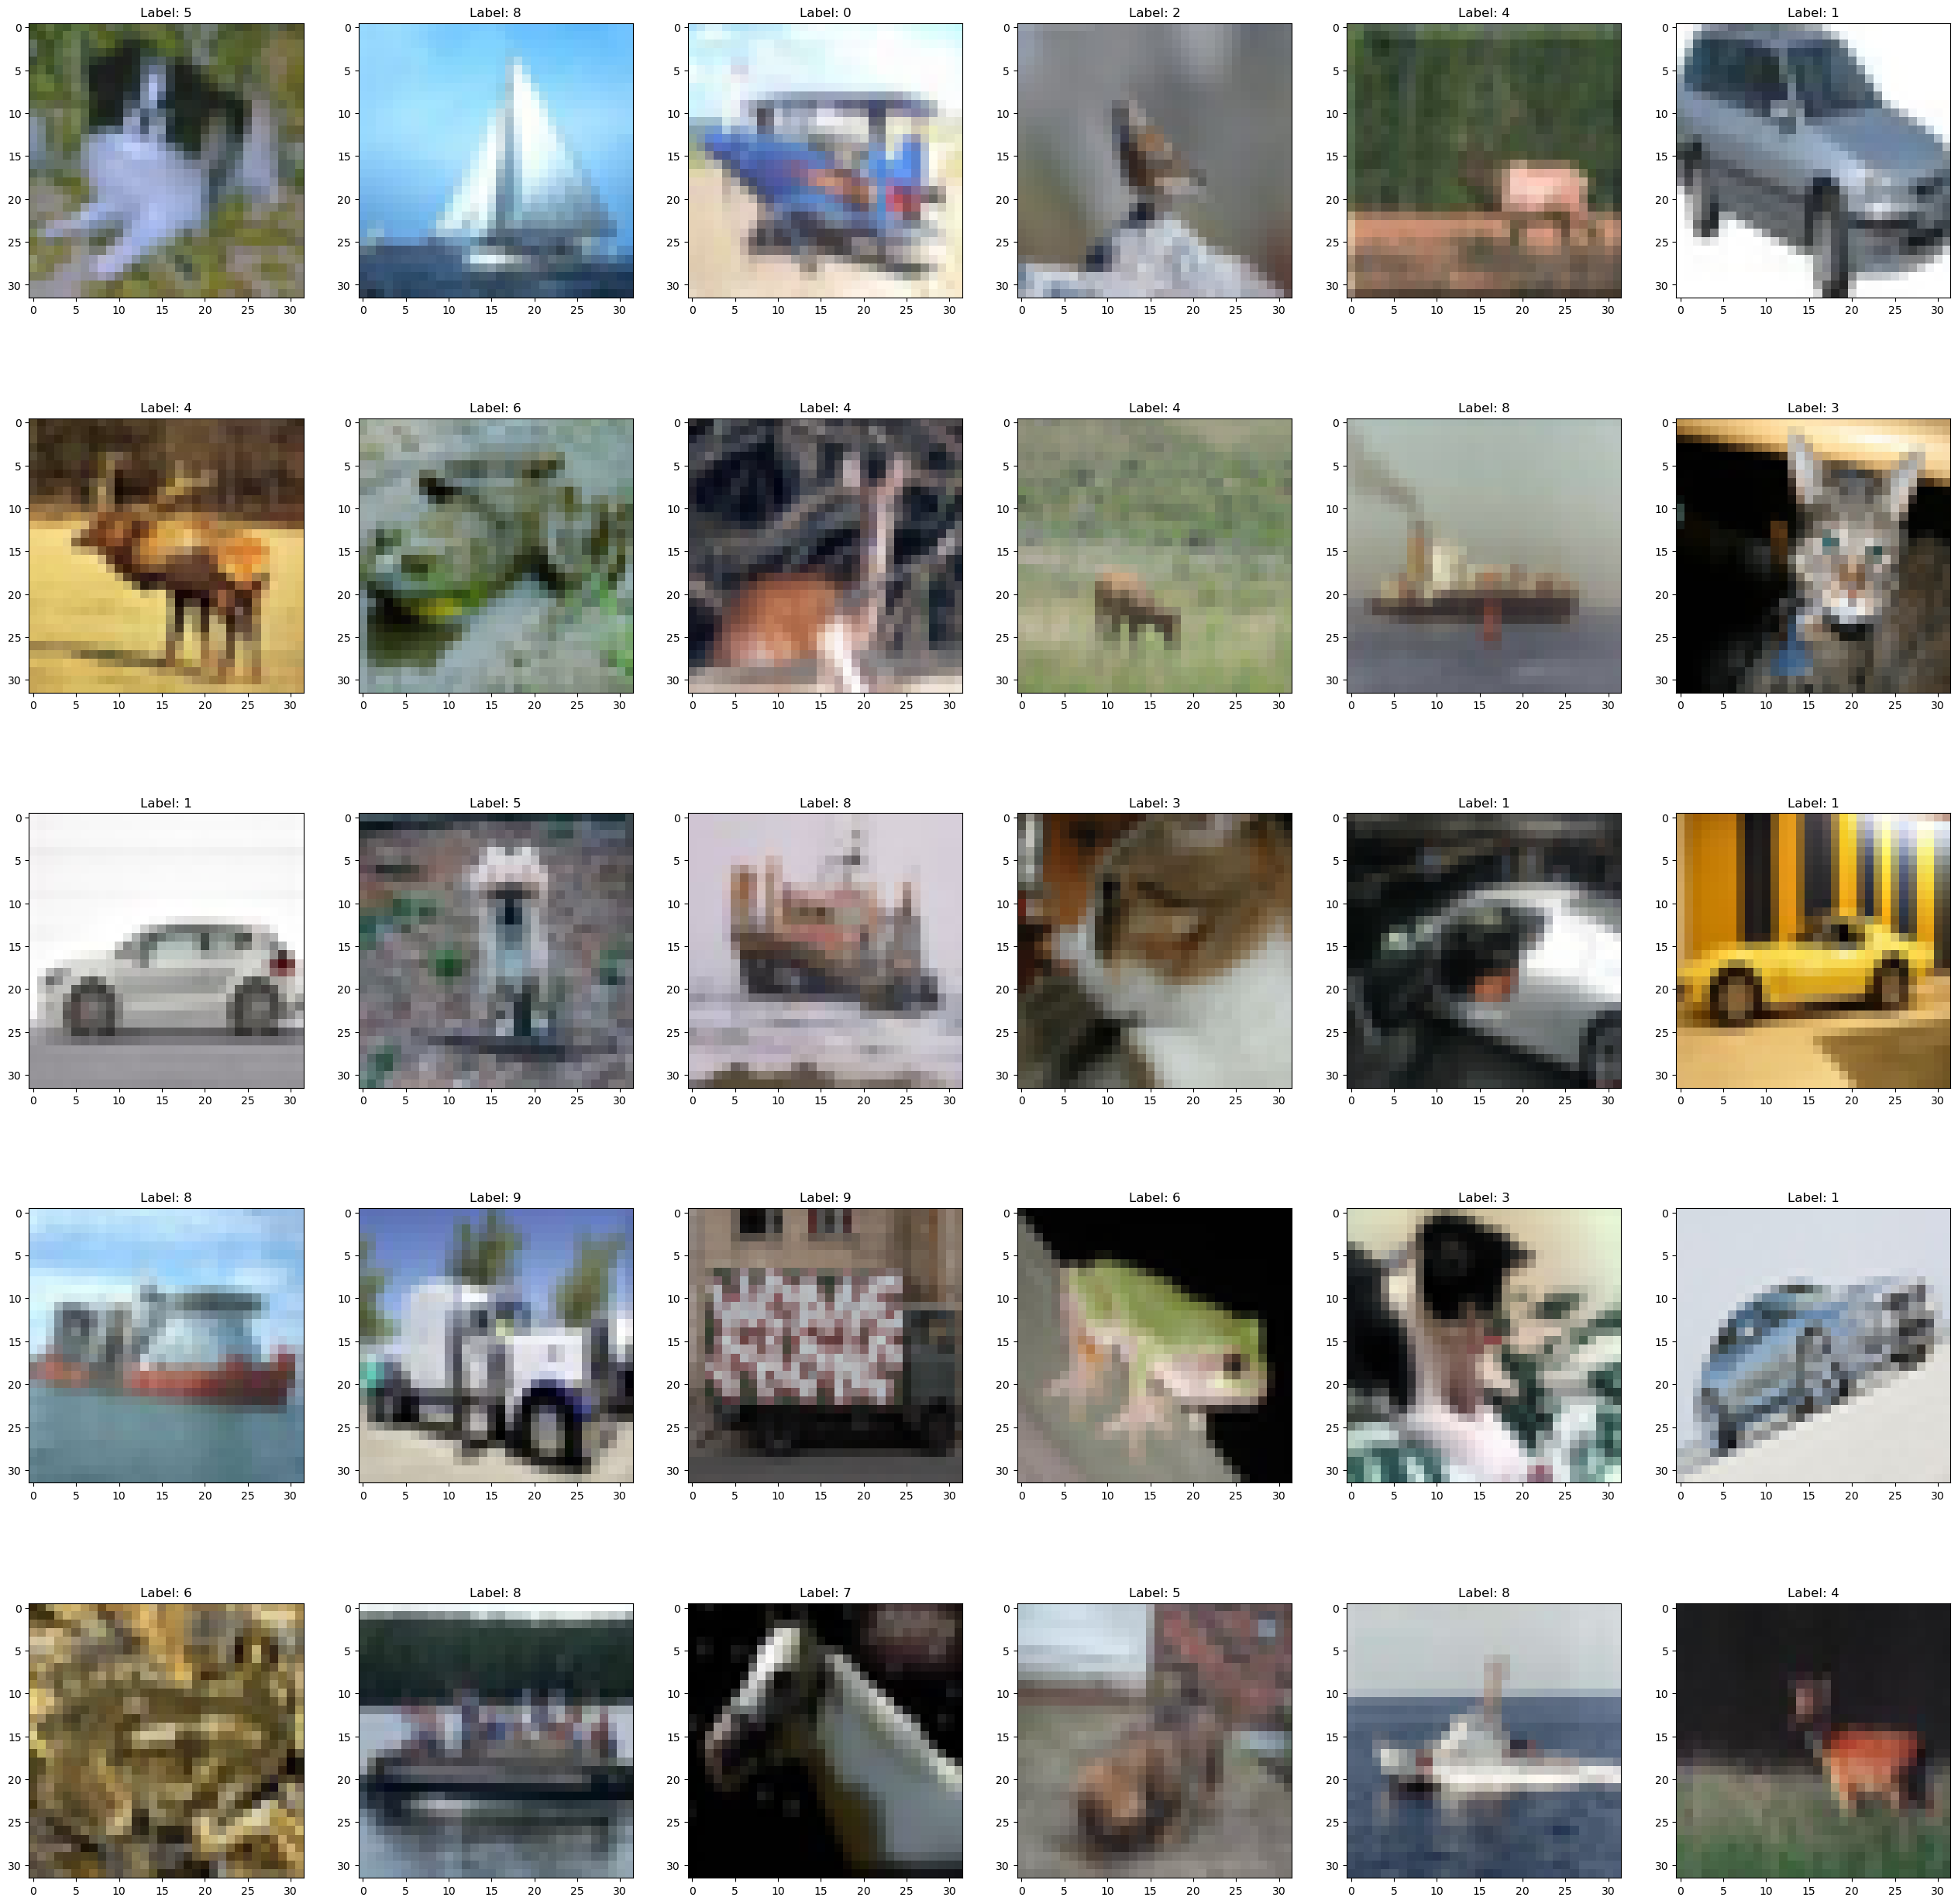

In [ ]:
# Disaplying some samples from the development set
sample_indexes = np.random.choice(np.arange(X_dev.shape[0], dtype = int),size = 30, replace = False)
plt.figure(figsize = (32,32))
for (ii,jj) in enumerate(sample_indexes):
    plt.subplot(5,6,ii+1)
    plt.imshow(X_dev[jj], cmap = "viridis")
    plt.title("Label: %d" %Y_dev[jj])
plt.show()

In [ ]:
#The number of classes across samples looks balanced
# Let's shuffle the samples and split them

indexes = np.arange(X_dev.shape[0], dtype = int)
np.random.shuffle(indexes)
X_dev = X_dev[indexes]
Y_dev = Y_dev[indexes]

nsplit = int(0.75*X_dev.shape[0]) # Train/validation split

# Train and validation split

# Include your solution below
# !!!!
X_train = X_dev[:nsplit]
Y_train = Y_dev[:nsplit]
X_val = X_dev[nsplit:]
Y_val = Y_dev[nsplit:]
# !!!!

print("\nTrain set")
print("Images: ",X_train.shape)
print("Labels shape: ",Y_train.shape)
print("\nValidation set")
print("Images: ",X_val.shape)
print("Labels shape: ",Y_val.shape)


Train set
Images:  (37500, 32, 32, 3)
Labels shape:  (37500, 1)

Validation set
Images:  (12500, 32, 32, 3)
Labels shape:  (12500, 1)


In [ ]:
print(X_train.min(),X_train.max(),X_train.mean(),X_train.std())
print(X_val.min(),X_val.max(),X_val.mean(),X_val.std())

0 255 120.70980572048612 64.16926618487612
0 255 120.70084333333334 64.09247006463943


## 2. Data Scaling

In [ ]:
norm_type = 0 # 0 -> min-max; 1-> standardization

if norm_type == 0:
    X_train = X_train/255
    X_val = X_val/255
    X_test = X_test/255
elif norm_type == 1:
    train_mean, train_std = X_train.mean(),X_train.std()
    X_train = (X_train - train_mean)/train_std
    X_val = (X_val - train_mean)/train_std
    X_test = (X_test - train_mean)/train_std
else:
    pass

## 3. One hot encoding

In [ ]:
# Include your solution below
# !!!!
Y_train_oh = tf.keras.utils.to_categorical(Y_train)
Y_val_oh = tf.keras.utils.to_categorical(Y_val)
Y_test_oh = tf.keras.utils.to_categorical(Y_test)
# !!!!

print("Labels:")
print(Y_train[:5])
print()
print("One hot encoded labels:")
print(Y_train_oh[:5])

Labels:
[[0]
 [7]
 [6]
 [1]
 [0]]

One hot encoded labels:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


## 4. Define your model, cost function, optimizer, learning rate

In [ ]:
# you must create a convolutional neural network model with 8 layers (1 input layer, 3 convolutional layers,
# 2 dropout layers, 1 max pooling layer, 1 output layer)

def my_model(ishape = (32,32,3),k = 10, lr = 1e-4):
    # Include your solution below
    model_input = tf.keras.layers.Input(shape = ishape)
    l1 = tf.keras.layers.Conv2D(48, (3,3), padding='same', activation='relu')(model_input)
    l2 = tf.keras.layers.Conv2D(48, (3,3), padding='same', activation='relu')(l1)
    l2_drop = tf.keras.layers.Dropout(0.25)(l2)
    l3 = tf.keras.layers.MaxPool2D((2,2))(l2_drop)
    l4 = tf.keras.layers.Conv2D(96, (3,3), padding='same', activation='relu')(l3)
    l4_drop = tf.keras.layers.Dropout(0.25)(l4)
    flat = tf.keras.layers.Flatten()(l4_drop)
    out = tf.keras.layers.Dense(k,activation = 'softmax')(flat)
    model = tf.keras.models.Model(inputs = model_input, outputs = out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='categorical_crossentropy', metrics = ["accuracy"])


    return model

In [ ]:
model = my_model()
print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 48)     │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 48)     │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 24576)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │       245,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 309,466 (1.18 MB)

 Trainable params: 309,466 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

None


## 5. Define your callbacks (save your model, patience, etc.)

- [Keras callbacks](https://keras.io/api/callbacks/)

In [ ]:
model_name = "best_model_mnist_cnn.weights.h5"
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience = 20)

monitor = tf.keras.callbacks.ModelCheckpoint(model_name, monitor='val_loss',\
                                             verbose=0,save_best_only=True,\
                                             save_weights_only=True,\
                                             mode='min')
# Learning rate schedule
def scheduler(epoch, lr):
    if epoch%10 == 0:
        lr = lr/2
    return lr

lr_schedule = tf.keras.callbacks.LearningRateScheduler(scheduler,verbose = 0)

## 6. Train your model

In [ ]:
my_epochs = 10
my_batch_size = 32

model.fit(X_train, Y_train_oh, batch_size = my_batch_size, epochs = my_epochs, \
          verbose = 1, callbacks= [early_stop, monitor, lr_schedule],validation_data=(X_val,Y_val_oh))

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.2854 - loss: 1.9759 - val_accuracy: 0.4474 - val_loss: 1.5999 - learning_rate: 5.0000e-05
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.4670 - loss: 1.5019 - val_accuracy: 0.4987 - val_loss: 1.4398 - learning_rate: 5.0000e-05
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 48s 41ms/step - accuracy: 0.5199 - loss: 1.3615 - val_accuracy: 0.5268 - val_loss: 1.3762 - learning_rate: 5.0000e-05
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 49s 42ms/step - accuracy: 0.5472 - loss: 1.2931 - val_accuracy: 0.5582 - val_loss: 1.2964 - learning_rate: 5.0000e-05
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 78s 67ms/step - accuracy: 0.5714 - loss: 1.2323 - val_accuracy: 0.5714 - val_loss: 1.2623 - learning_rate: 5.0000e-05
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 62s 53ms/step - accuracy: 0.5815 - loss: 1.1967 - val_accuracy: 0.5934 - val_loss: 1.2137 - learning_rate: 5.0000e-05
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━

## 7. Test your model on the test and extract relevant metrics

In [ ]:
model.load_weights(model_name)
metrics = model.evaluate(X_test,Y_test_oh)
print("Categorical cross-entropy:", metrics[0])
print("Accuracy:", metrics[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6206 - loss: 1.0974
Categorical cross-entropy: 1.1065375804901123
Accuracy: 0.6169000267982483


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
90000000


C:\Users\kyboo\AppData\Local\Temp\ipykernel_44604\2548371590.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title("Label: %d, predicted: %d" %(Y_test[wrong_indexes[jj]],Ypred[wrong_indexes[jj]]))


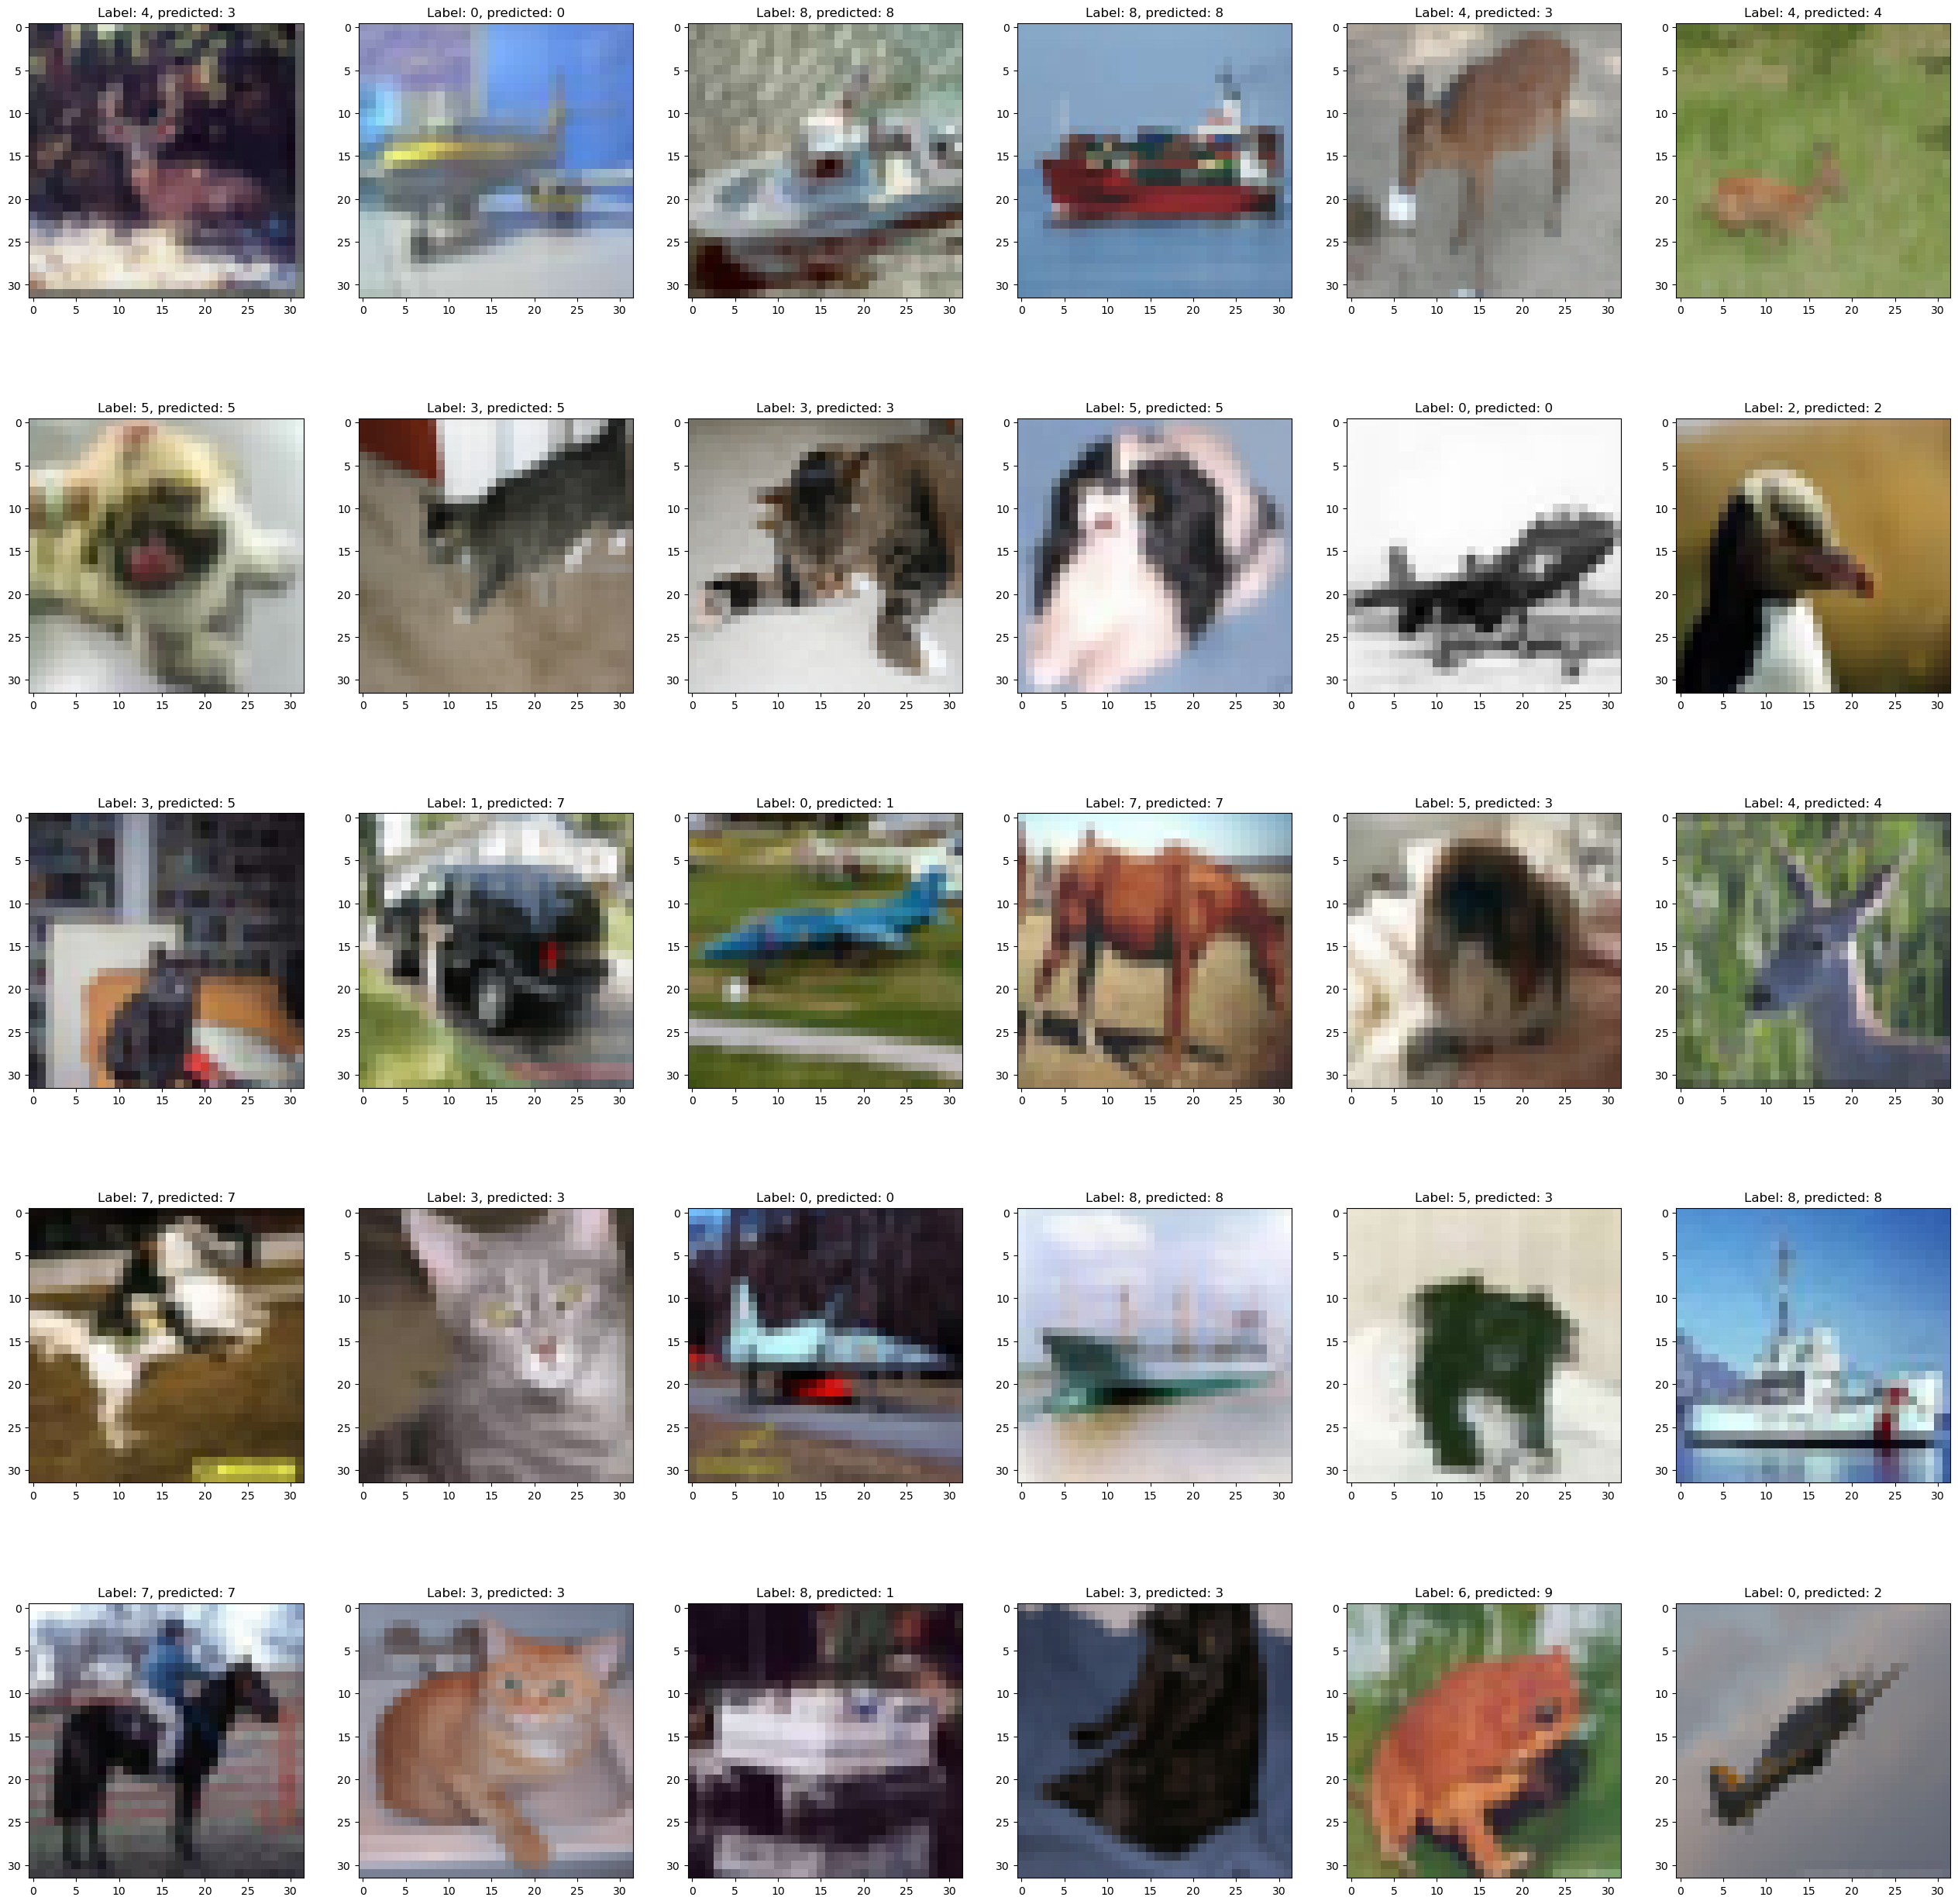

In [ ]:
Ypred = model.predict(X_test).argmax(axis = 1)
wrong_indexes = np.where(Ypred != Y_test)[0]
print(wrong_indexes.size)

# Disaplying some samples from the development set
sample_indexes = np.random.choice(np.arange(wrong_indexes.shape[0], dtype = int),size = 30, replace = False)
plt.figure(figsize = (32,32))
for (ii,jj) in enumerate(sample_indexes):
    plt.subplot(5,6,ii+1)
    plt.imshow(X_test[wrong_indexes[jj]], cmap = "viridis")
    plt.title("Label: %d, predicted: %d" %(Y_test[wrong_indexes[jj]],Ypred[wrong_indexes[jj]]))
plt.show()